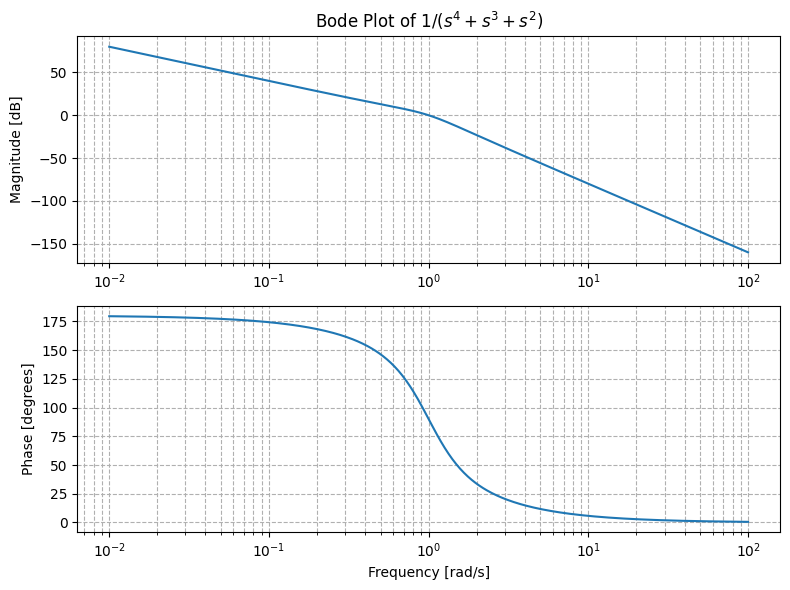

In [1]:
import matplotlib.pyplot as plt
import scipy.signal as signal
import numpy as np

# Define the transfer function H(s) = 1 / (s^4 + s^3 + s^2)
# The denominator polynomial is s^4 + 1*s^3 + 1*s^2 + 0*s + 0
numerator = [1]
denominator = [1, 1, 1, 0, 0]

# Create the transfer function model
system = signal.TransferFunction(numerator, denominator)

# Specify a frequency range to analyze
w = np.logspace(-2, 2, 500)

# Calculate the Bode plot data
w, mag, phase = signal.bode(system, w)

# Create the plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

# Magnitude Plot
ax1.semilogx(w, mag)
ax1.set_ylabel('Magnitude [dB]')
ax1.set_title('Bode Plot of $1/(s^4 + s^3 + s^2)$')
ax1.grid(which='both', linestyle='--')

# Phase Plot
ax2.semilogx(w, phase)
ax2.set_xlabel('Frequency [rad/s]')
ax2.set_ylabel('Phase [degrees]')
ax2.grid(which='both', linestyle='--')

# Display the plot
plt.tight_layout()
plt.show()

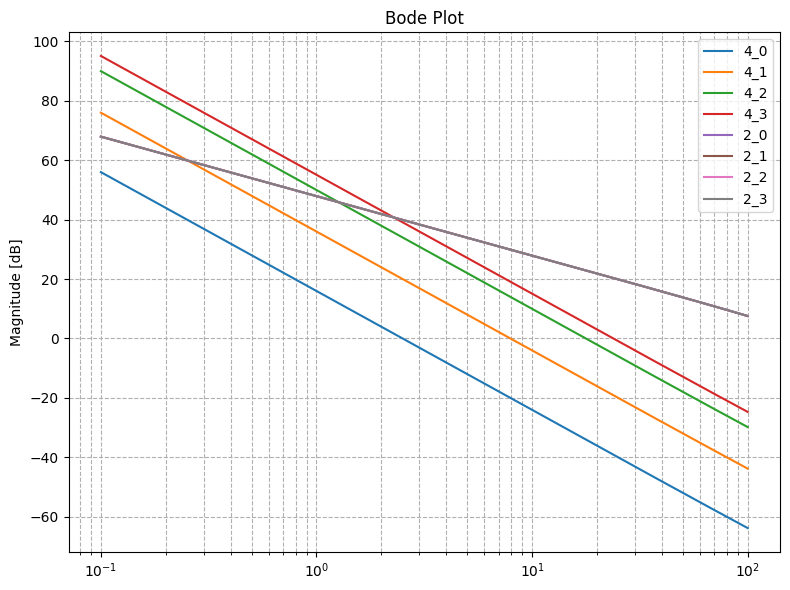

In [41]:
m = 1.4e-5
d = 2e-3
B = 0.8e-6
C = 3.22e-9

B, C, J, wb = B, C, 1/6*(m*d**2), 50*2*np.pi

mag1s = []
mag2s = []

for i in [1,10,50,90]:
    wb = i * 2 * np.pi
    num1 = [B*wb]
    den1 = [J, C, B, 0 ,0]
    num2 = [B]
    den2 = [J, C, 0]

    sys1 = signal.TransferFunction(num1, den1)
    sys2 = signal.TransferFunction(num2, den2)

    w = np.logspace(-1,2, 500)

    w1, mag1, ph1 = signal.bode(sys1, w)
    w2, mag2, ph2 = signal.bode(sys2, w)

    mag1s.append(mag1)
    mag2s.append(mag2)

# Create the plot
fig, (ax1) = plt.subplots(1, 1, figsize=(8, 6))

# Magnitude Plot
# ax1.semilogx(w, mag1, label="4th order")
# ax1.semilogx(w, mag2, label="2nd order")
for i, mag in enumerate(mag1s):
    ax1.semilogx(w, mag, label=f"4_{i}")
for i, mag in enumerate(mag2s):
    ax1.semilogx(w, mag, label=f"2_{i}")
ax1.set_ylabel('Magnitude [dB]')
ax1.set_title('Bode Plot')
ax1.grid(which='both', linestyle='--')

# Display the plot
plt.legend()
plt.tight_layout()
plt.show()

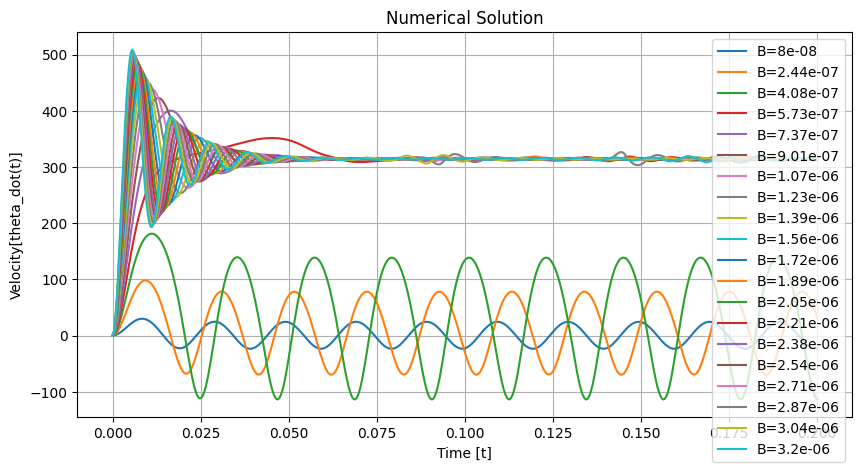

step out field 4.0842105263157895e-07 Nm


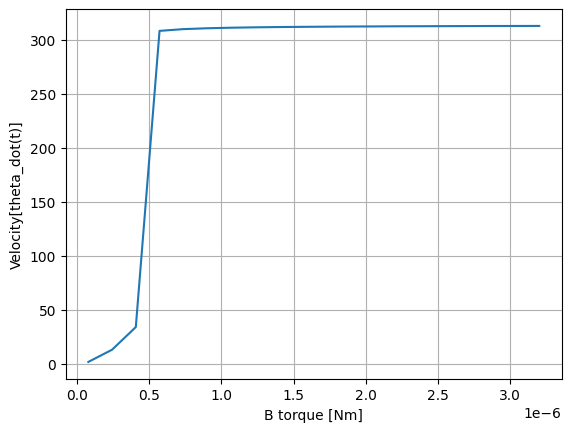

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from functools import partial

# Define the system of first-order differential equations
# y is a vector [x, v], where y[0] = x and y[1] = v = x_dot
# t is the time

m = 1.4e-5
d = 2e-3
J = 1/6 * m * d**2
B = 0.8e-6
C = 3.22e-9 / 2
wb = 50*2*np.pi

vels = []
mag_mult = np.linspace(0.1,2,20)
v_means = []

for i in mag_mult:
    def model(t, y, B, wb, C, J):
        theta1, theta2 = y
        theta1d = theta2
        theta2d = (B*np.sin(wb*t - theta1) - C*theta2)/J
        return [theta1d, theta2d]

    # Set the initial conditions
    x_initial = 0.0  # Initial position: x(0)
    v_initial = 0.0  # Initial velocity: x_dot(0)
    initial_conditions = [x_initial, v_initial]

    # Set the time interval to solve for
    t_span = [0, 0.2] # from t=0 to t=20
    t_eval = np.linspace(t_span[0], t_span[1], 500) # points where solution is saved

    # Use the numerical solver
    # 'solve_ivp' stands for "solve initial value problem"
    solution = solve_ivp(
        fun=partial(model, B=B*i, wb=wb, C=C, J=J),
        t_span=t_span,
        y0=initial_conditions,
        t_eval=t_eval
    )

    # Extract the results
    t = solution.t
    x = solution.y[0]
    v = solution.y[1]
    v_mean = np.mean(v)
    v_means.append(v_mean)
    vels.append(v)

b_fields = B*mag_mult

# Plot the solution
plt.figure(figsize=(10, 5))
for idx, vl in enumerate(vels): plt.plot(t, vl, label=f"B={b_fields[idx]:.3g}")
plt.title('Numerical Solution')
plt.xlabel('Time [t]')
plt.ylabel('Velocity[theta_dot(t)]')
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(b_fields, v_means)
plt.ylabel('Velocity[theta_dot(t)]')
plt.xlabel('B torque [Nm]')
plt.grid()

step_out = b_fields[np.argmax(np.diff(v_means))]
print(f"step out field {step_out} Nm")

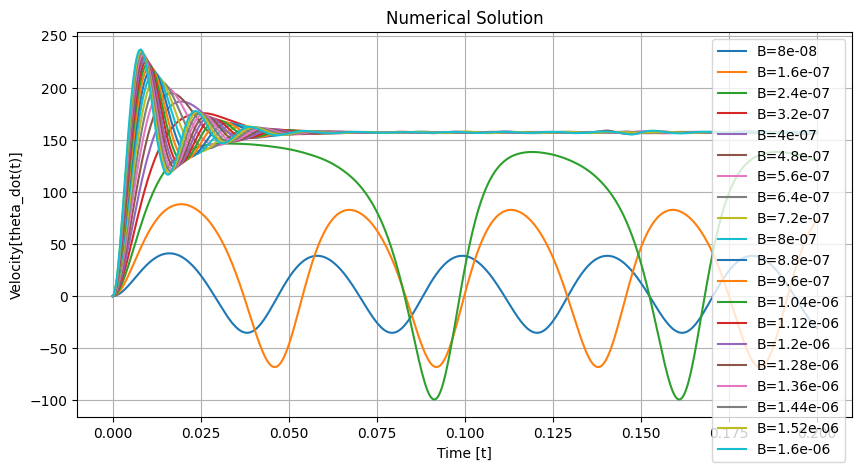

step out field 2.4e-07 Nm


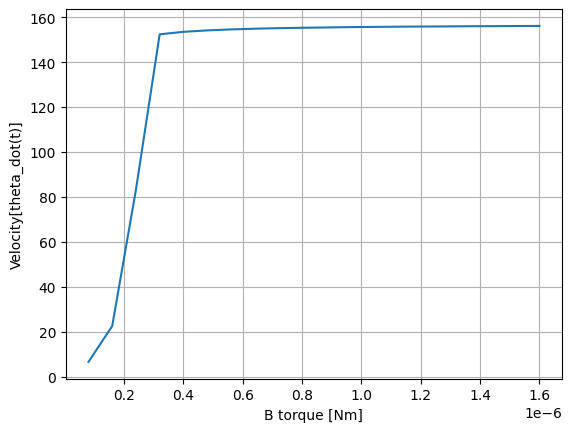

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from functools import partial

# Define the system of first-order differential equations
# y is a vector [x, v], where y[0] = x and y[1] = v = x_dot
# t is the time

m = 1.4e-5
d = 2e-3
J = 1/6 * m * d**2
B = 0.8e-6
C = 3.22e-9 / 2
wb = 25*2*np.pi

vels = []
mag_mult = np.linspace(0.1,2,20)
v_means = []

for i in mag_mult:
    def model(t, y, B, wb, C, J):
        theta1, theta2 = y
        theta1d = theta2
        theta2d = (B*np.sin(wb*t - theta1) - C*theta2)/J
        return [theta1d, theta2d]

    # Set the initial conditions
    x_initial = 0.0  # Initial position: x(0)
    v_initial = 0.0  # Initial velocity: x_dot(0)
    initial_conditions = [x_initial, v_initial]

    # Set the time interval to solve for
    t_span = [0, 0.2] # from t=0 to t=20
    t_eval = np.linspace(t_span[0], t_span[1], 500) # points where solution is saved

    # Use the numerical solver
    # 'solve_ivp' stands for "solve initial value problem"
    solution = solve_ivp(
        fun=partial(model, B=B*i, wb=wb, C=C, J=J),
        t_span=t_span,
        y0=initial_conditions,
        t_eval=t_eval
    )

    # Extract the results
    t = solution.t
    x = solution.y[0]
    v = solution.y[1]
    v_mean = np.mean(v)
    v_means.append(v_mean)
    vels.append(v)

b_fields = B*mag_mult

# Plot the solution
plt.figure(figsize=(10, 5))
for idx, vl in enumerate(vels): plt.plot(t, vl, label=f"B={b_fields[idx]:.3g}")
plt.title('Numerical Solution')
plt.xlabel('Time [t]')
plt.ylabel('Velocity[theta_dot(t)]')
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(b_fields, v_means)
plt.ylabel('Velocity[theta_dot(t)]')
plt.xlabel('B torque [Nm]')
plt.grid()

step_out = b_fields[np.argmax(np.diff(v_means))]
print(f"step out field {step_out} Nm")

In [86]:
for i in range(1,90+10,10):
    print(i)

1
11
21
31
41
51
61
71
81
91


In [ ]:
fig = plt.figure()

x = np.linspace(-100,100,1000)


1


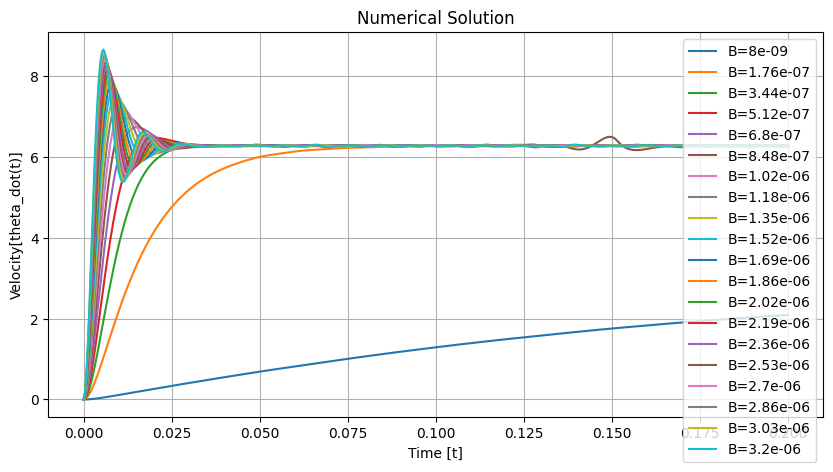

step out field 8e-09 Nm
11


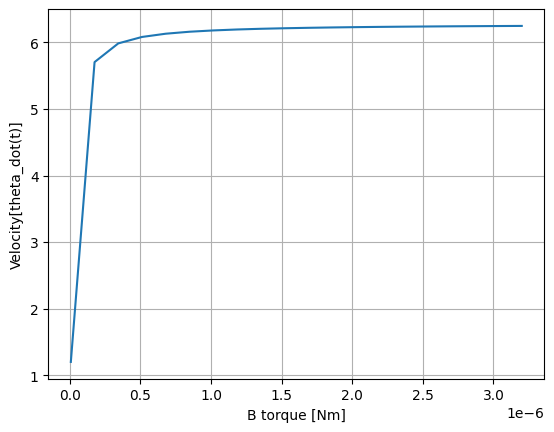

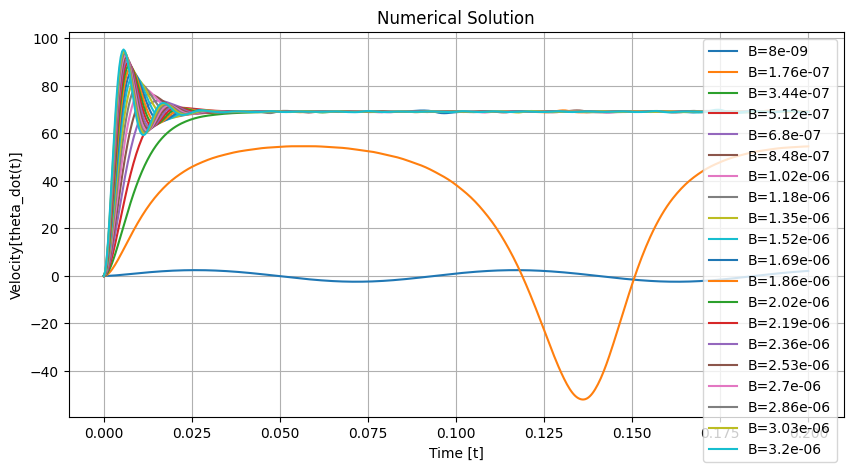

step out field 1.7600000000000001e-07 Nm
21


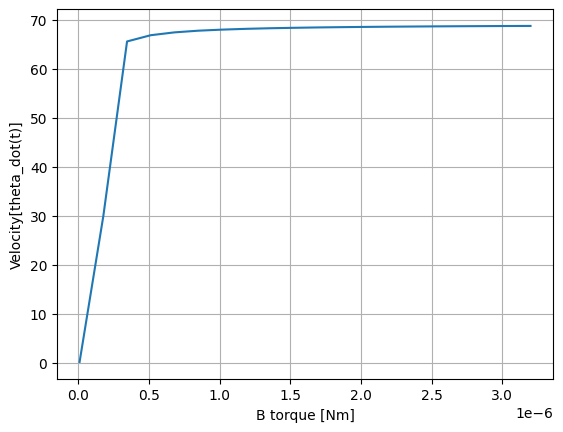

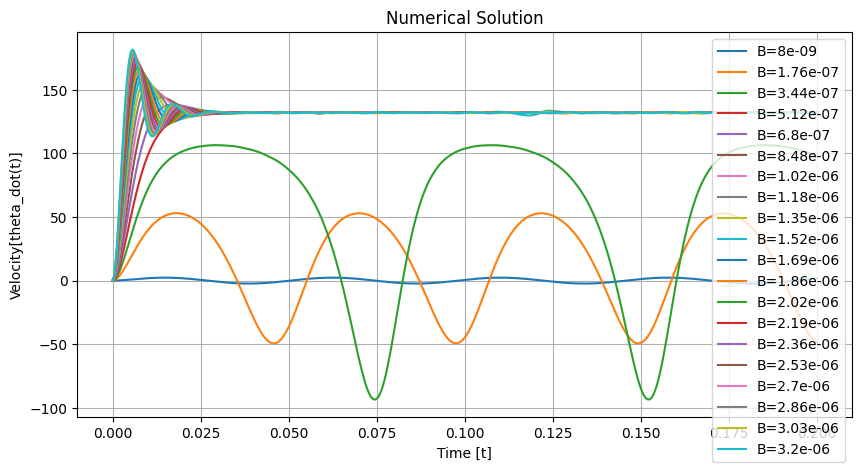

step out field 3.44e-07 Nm
31


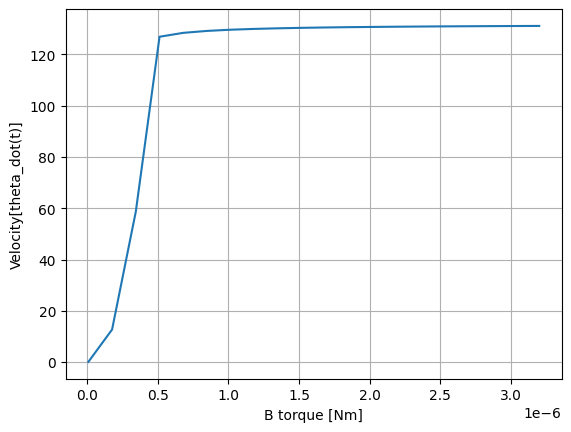

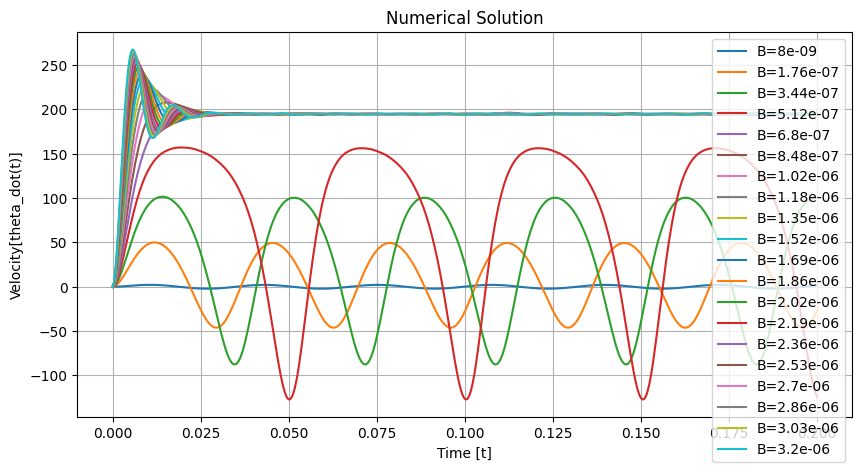

step out field 5.12e-07 Nm
41


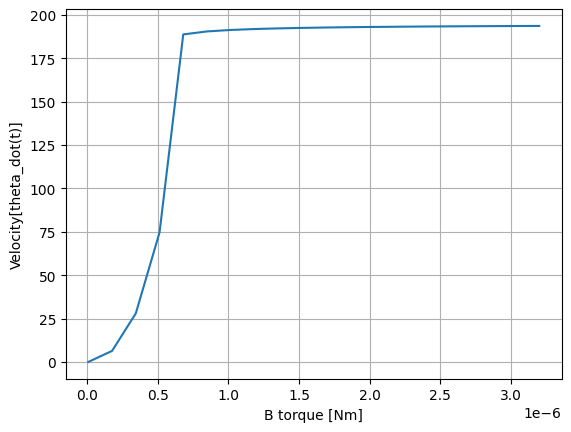

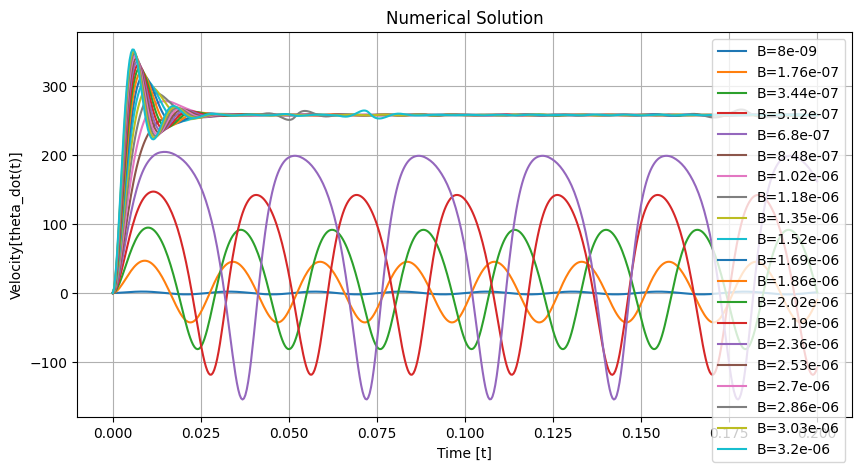

step out field 6.800000000000001e-07 Nm
51


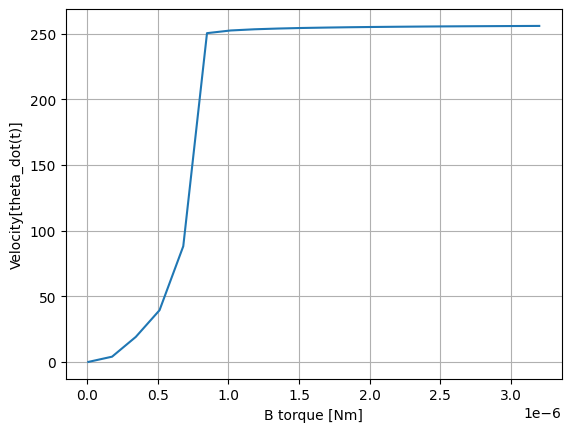

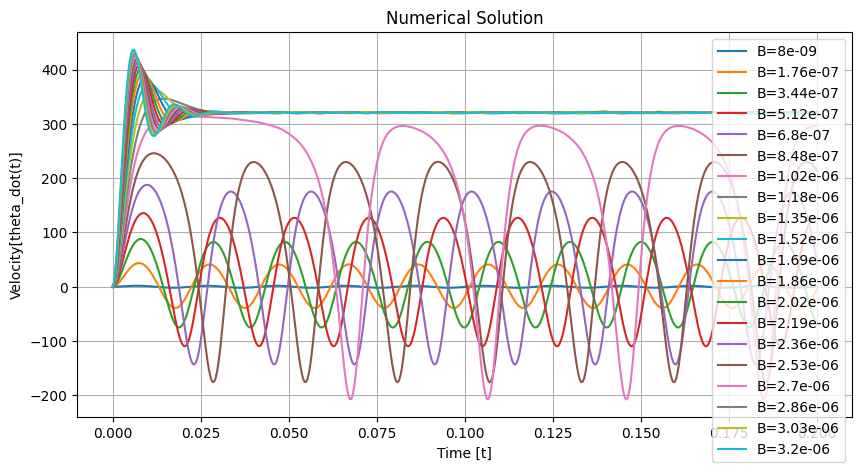

step out field 1.016e-06 Nm
61


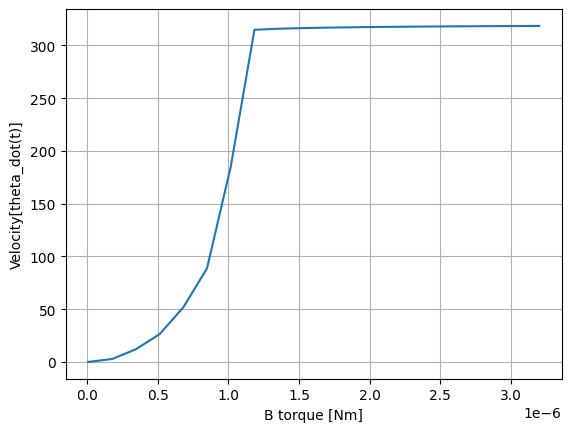

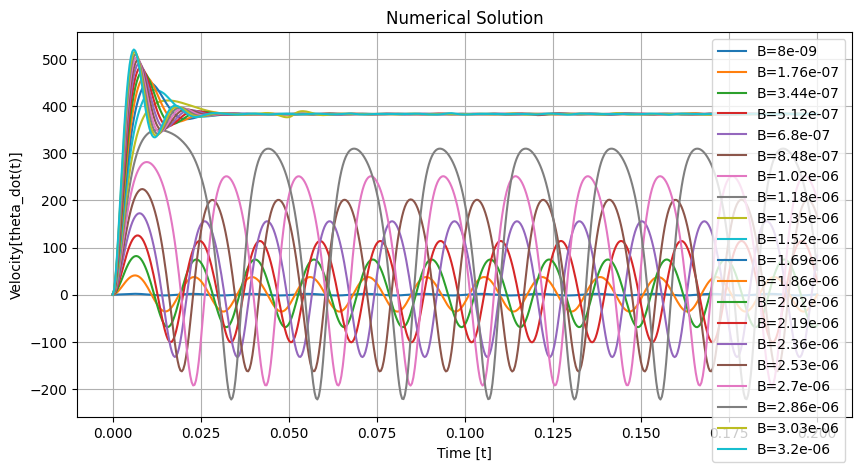

step out field 1.184e-06 Nm
71


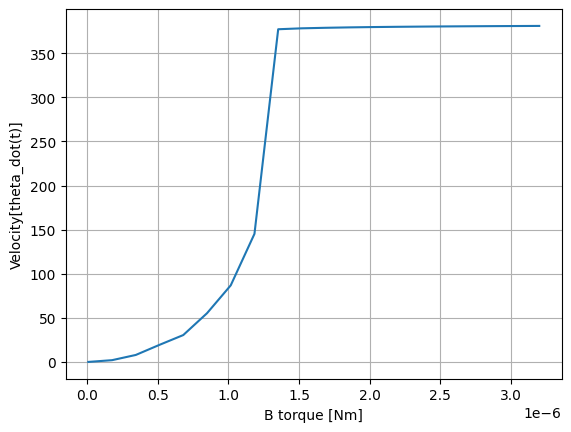

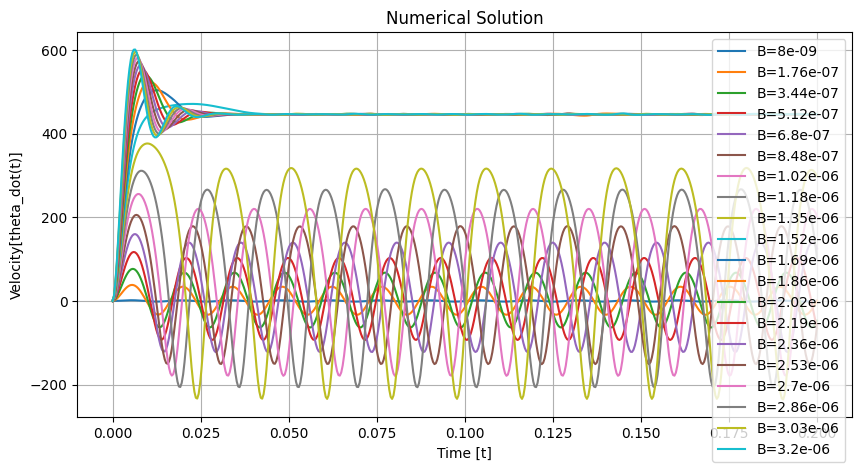

step out field 1.3520000000000001e-06 Nm
81


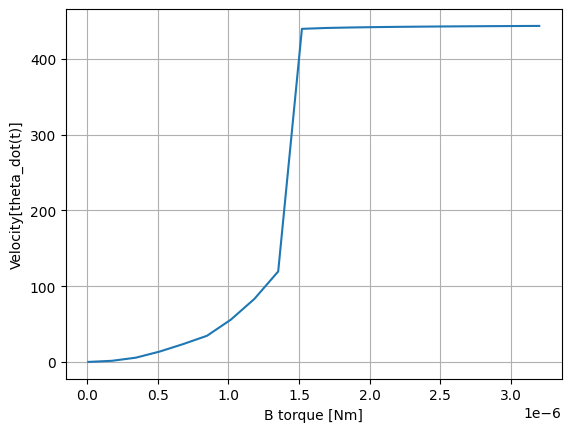

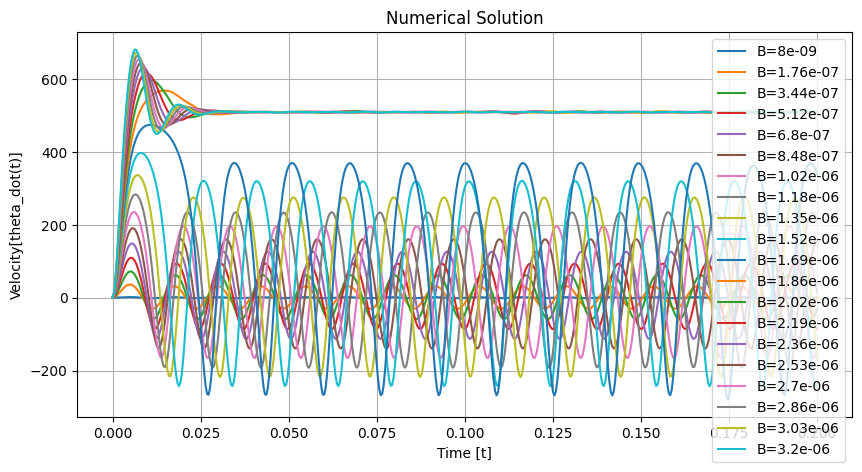

step out field 1.6879999999999998e-06 Nm
91


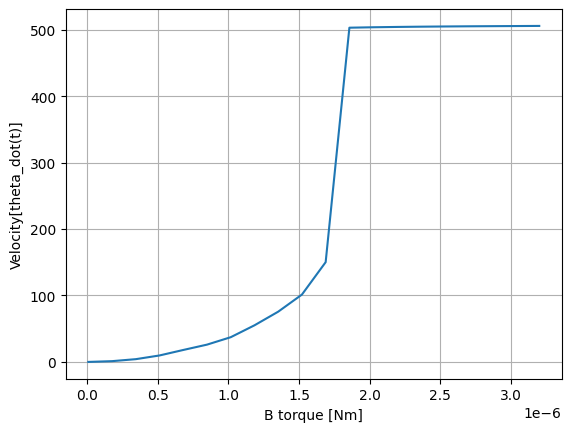

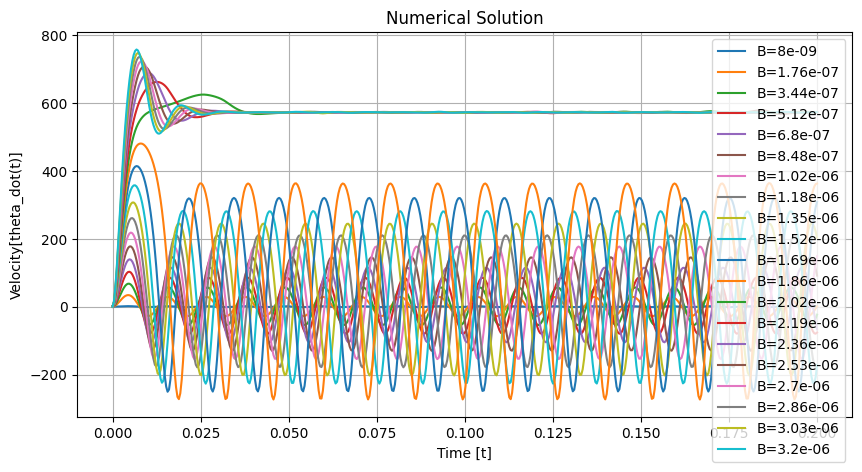

step out field 1.8559999999999999e-06 Nm


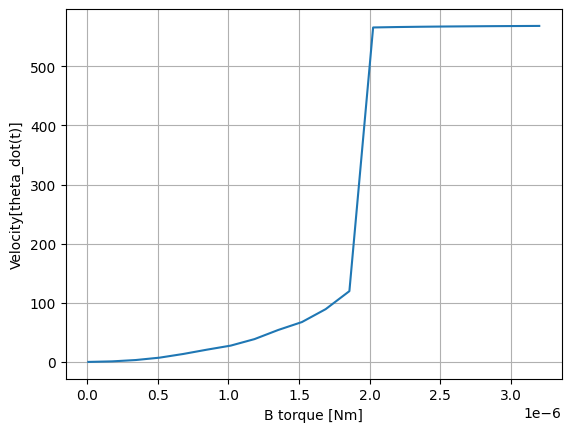

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from functools import partial

# Define the system of first-order differential equations
# y is a vector [x, v], where y[0] = x and y[1] = v = x_dot
# t is the time

m = 1.4e-5
d = 2e-3
J = 1/6 * m * d**2
B = 0.8e-6
C = 3.22e-9
# wb = 25*2*np.pi

wbs = []
mag_mult = np.linspace(0.01,4,20)
step_outs = []

def wrap(theta_diff):
    return theta_diff - 2*np.pi * np.floor((theta_diff+np.pi)/np.pi/2)

for j in range(1,90+10,10):
    wb = 2*np.pi * j
    print(j)
    v_means = []
    vels = []
    for i in mag_mult:
        def model(t, y, B, wb, C, J):
            theta1, theta2 = y
            theta1d = theta2
            theta2d = (B*np.sin(wrap(wb*t - theta1)) - C*theta2)/J
            return [theta1d, theta2d]

        # Set the initial conditions
        x_initial = 0.0  # Initial position: x(0)
        v_initial = 0.0  # Initial velocity: x_dot(0)
        initial_conditions = [x_initial, v_initial]

        # Set the time interval to solve for
        t_span = [0, 0.2] # from t=0 to t=20
        t_eval = np.linspace(t_span[0], t_span[1], 500) # points where solution is saved

        # Use the numerical solver
        # 'solve_ivp' stands for "solve initial value problem"
        solution = solve_ivp(
            fun=partial(model, B=B*i, wb=wb, C=C, J=J),
            t_span=t_span,
            y0=initial_conditions,
            t_eval=t_eval
        )

        # Extract the results
        t = solution.t
        x = solution.y[0]
        v = solution.y[1]
        v_mean = np.mean(v)
        v_means.append(v_mean)
        vels.append(v)

    b_fields = B*mag_mult

    # Plot the solution
    plt.figure(figsize=(10, 5))
    for idx, vl in enumerate(vels): plt.plot(t, vl, label=f"B={b_fields[idx]:.3g}")
    plt.title('Numerical Solution')
    plt.xlabel('Time [t]')
    plt.ylabel('Velocity[theta_dot(t)]')
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(b_fields, v_means)
    plt.ylabel('Velocity[theta_dot(t)]')
    plt.xlabel('B torque [Nm]')
    plt.grid()

    step_out = b_fields[np.argmax(abs(np.diff(v_means)))]
    step_outs.append(step_out)
    wbs.append(wb)
    print(f"step out field {step_out} Nm")

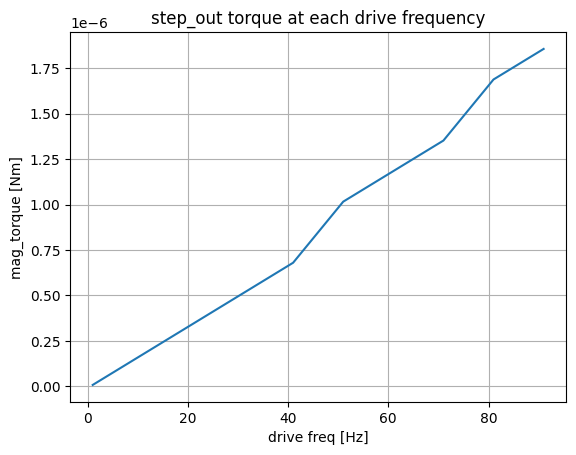

In [14]:
fig = plt.figure()
plt.plot(np.array(wbs)/2/np.pi, step_outs)
plt.xlabel("drive freq [Hz]")
plt.ylabel("mag_torque [Nm]")
plt.title("step_out torque at each drive frequency")
plt.grid()